In [1]:
import numpy as np
import pandas as pd
import cvxpy as cp
from scipy.spatial import KDTree
from scipy.interpolate import interp1d
import plotly.graph_objects as go
from Functions.Utils import *
from Functions.Graphs import *
from scipy.interpolate import CubicSpline
from sklearn.metrics import root_mean_squared_error as RMSE

import optuna
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_pareto_front
from optuna.importance import get_param_importances
from optuna.samplers import RandomSampler
from optuna.exceptions import TrialPruned

def SelSampler(mode='auto'):
    '''mode: auto, random,  tpe'''
    if mode == 'auto':
        sampler = None
    elif mode == 'tpe':
        # Mantendo multivariate=True para capturar a correlação entre os pesos do MPC
        # Ajustado n_startup_trials=100 para condizer bem com seus 500 n_trials totais
        sampler = optuna.samplers.TPESampler(
            multivariate=True, 
            n_startup_trials=100
        )
    elif mode == 'random':
        sampler = RandomSampler()
    return sampler

(CVXPY) Jun 25 12:19:02 PM: Encountered unexpected exception importing solver CUCLARABEL:
ImportError("\n================================================================\nFailed to import CuPy.\n\nIf you installed CuPy via wheels (cupy-cudaXXX or cupy-rocm-X-X), make sure that the package matches with the version of CUDA or ROCm installed.\n\nOn Linux, you may need to set LD_LIBRARY_PATH environment variable depending on how you installed CUDA/ROCm.\nOn Windows, try setting CUDA_PATH environment variable.\n\nCheck the Installation Guide for details:\n  https://docs.cupy.dev/en/latest/install.html\n\nCUDA Path: C:\\Program Files\\NVIDIA GPU Computing Toolkit\\CUDA\\v13.2\nDLL dependencies:\n  KERNEL32.dll -> C:\\WINDOWS\\System32\\KERNEL32.DLL\n  MSVCP140.dll -> C:\\WINDOWS\\SYSTEM32\\MSVCP140.dll\n  VCRUNTIME140.dll -> c:\\Users\\Claudio\\AppData\\Local\\Programs\\Python\\Python310\\VCRUNTIME140.dll\n  VCRUNTIME140_1.dll -> c:\\Users\\Claudio\\AppData\\Local\\Programs\\Python\\Python31

In [2]:


# --- Adaptive Turning Speed Function ---
def TurningSpeed(u_control_1, V_cruising, V_turning):
    angulo_abs = abs(u_control_1)
    pontos_angulo = np.linspace(0, 30, 2000)
    pontos_velocidade = np.flip(np.linspace(V_turning, V_cruising, 2000))
    V_ref = np.interp(angulo_abs, pontos_angulo, pontos_velocidade)
    return float(V_ref)

# --- Linearized Kinematic Bicycle Model Matrices ---
def get_linear_model_matrices(x_nominal, u_nominal, dt, l=2.5):
    """
    Returns the linearized state-space matrices A and B such that:
    x_{k+1} = A*x_k + B*u_k + c
    States: [x, y, v, psi]
    Controls: [a, delta]
    """
    _, _, v, psi = x_nominal
    a, delta = u_nominal
    
    beta = np.arctan(0.5 * np.tan(delta))
    
    # Cosine/sine derivatives evaluations
    cos_psi_beta = np.cos(psi + beta)
    sin_psi_beta = np.sin(psi + beta)
    
    # Partial derivatives for A matrix (Jacobian w.r.t State)
    # dx_next/dx = 1, dx_next/dy = 0, dx_next/dv = dt*cos, dx_next/dpsi = -dt*v*sin
    A = np.array([
        [1.0, 0.0, dt * cos_psi_beta, -dt * v * sin_psi_beta],
        [0.0, 1.0, dt * sin_psi_beta,  dt * v * cos_psi_beta],
        [0.0, 0.0, 1.0,                0.0],
        [0.0, 0.0, dt * np.sin(beta)/l, 1.0]
    ])
    
    # Partial derivatives w.r.t delta (Chain rule via beta)
    dbeta_ddelta = 0.5 * (1 + np.tan(delta)**2) / (1 + (0.5 * np.tan(delta))**2)
    dx_ddelta = -dt * v * sin_psi_beta * dbeta_ddelta
    dy_ddelta = dt * v * cos_psi_beta * dbeta_ddelta
    dpsi_ddelta = dt * (v / l) * np.cos(beta) * dbeta_ddelta
    
    # B matrix (Jacobian w.r.t Controls)
    B = np.array([
        [0.0, dx_ddelta],
        [0.0, dy_ddelta],
        [dt,  0.0],
        [0.0, dpsi_ddelta]
    ])
    
    # Affine constant term to offset linearization point mismatch
    x_next_nominal = np.array([
        x_nominal[0] + dt * v * cos_psi_beta,
        x_nominal[1] + dt * v * sin_psi_beta,
        v + dt * a,
        psi + dt * (v / l) * np.sin(beta)
    ])
    c = x_next_nominal - A @ x_nominal - B @ u_nominal
    
    return A, B, c

In [16]:
def SimulateRT(dt=0.25,n_horizon = 20,sim_steps = 800,
               W_X = 1,W_Y = 1,W_speed = 10 ,W_acc = 1.5,W_delta = 0.25,W_U0 = 1,W_U1 = 2,
               size=1,show=False):
    # --- Track Data Loading & Setup ---
    # Update path matching your local setup

    BreakCheck = False
    path = r'DyntheticDataset\RaceTrack4.csv' 
    df = pd.read_csv(path)
    x_mid = df['x_coords'].values[:] * size
    y_mid = df['y_coords'].values[:] * size

    track_points = np.vstack((x_mid, y_mid)).T
    track_tree = KDTree(track_points)

    dx = np.diff(x_mid)
    dy = np.diff(y_mid)
    segment_lengths = np.sqrt(dx**2 + dy**2)
    s_coor = np.insert(np.cumsum(segment_lengths), 0, 0.0)
    track_length = s_coor[-1]

    get_x_at_s = interp1d(s_coor, x_mid, kind='linear', bounds_error=False, fill_value="extrapolate")
    get_y_at_s = interp1d(s_coor, y_mid, kind='linear', bounds_error=False, fill_value="extrapolate")

    # --- MPC Simulation Configuration ---
    V_cruising = 16
    V_turning = 8
    track_percentual = 0.9
    l = 2.5 

    # Initialization
    s_total_traveled = 0.0
    last_current_idx = 0
    x_current = np.array([x_mid[0], y_mid[0], 0.0, 0.0])
    u_prev = np.array([0.0, 0.0])

    # History collections
    t_history = [0.0]
    x_history = [x_current[0]]
    y_history = [x_current[1]]
    v_history = [x_current[2]]
    v_ref_history = [0.0]
    acc_history = [0.0]
    delta_history = [0.0]
    turning_history = [0]
    psi_history = [0]

    is_turning_sharp = False

    # --- Closed Loop Simulation Loop ---
    for step in range(sim_steps):
        if step % 50 == 0 and show: 
            print(f'Step: {step} | Speed: {x_current[2]:.2f} m/s | Distance traveled: {s_total_traveled:.2f} / {track_length:.2f} m')
            
        _, current_idx = track_tree.query([x_current[0], x_current[1]])
        
        idx_diff = current_idx - last_current_idx
        if idx_diff < -len(x_mid)/2: idx_diff += len(x_mid)
        elif idx_diff > len(x_mid)/2: idx_diff -= len(x_mid)
        if idx_diff > 0:
            s_total_traveled += np.sum(segment_lengths[last_current_idx:current_idx])
        last_current_idx = current_idx

        # References Profiles generation
        s_projected = s_coor[current_idx]
        x_ref_horizon = np.zeros(n_horizon)
        y_ref_horizon = np.zeros(n_horizon)
        v_ref_horizon = np.zeros(n_horizon)

        for k in range(n_horizon):
            s_projected += max(x_current[2], 1.5) * dt 
            s_wrapped = s_projected % track_length
            x_ref_horizon[k] = get_x_at_s(s_wrapped)
            y_ref_horizon[k] = get_y_at_s(s_wrapped)
            
            if s_total_traveled >= track_length * track_percentual:
                v_ref_horizon[k] = 0.0
            elif is_turning_sharp:
                v_ref_horizon[k] = TurningSpeed(np.rad2deg(u_prev[1]), V_cruising * 0.8, V_turning)
            else:
                v_ref_horizon[k] = V_cruising

        # --- Setup and Solve CVXPY Conic Problem via MOSEK ---
        X_cvx = cp.Variable((4, n_horizon + 1))
        U_cvx = cp.Variable((2, n_horizon))
        
        cost = 0
        constraints = [X_cvx[:, 0] == x_current]
        
        # Sequential Linearization around the current active state/input as the baseline nominal guess
        A_lin, B_lin, c_lin = get_linear_model_matrices(x_current, u_prev, dt, l)
        
        for k in range(n_horizon):
            # State dynamics (LTV formulation)
            constraints += [X_cvx[:, k+1] == A_lin @ X_cvx[:, k] + B_lin @ U_cvx[:, k] + c_lin]
            
            # State & Control Magnitude Tracking Objective Costs
            cost += W_X * cp.square(X_cvx[0, k] - x_ref_horizon[k])
            cost += W_Y * cp.square(X_cvx[1, k] - y_ref_horizon[k])
            cost += W_speed * cp.square(X_cvx[2, k] - v_ref_horizon[k])
            cost += W_acc * cp.square(U_cvx[0, k])
            cost += W_delta * cp.square(U_cvx[1, k])
            
            # Smooth Input Changes (Slew rates limits)
            if k == 0:
                cost += W_U0 * cp.square(U_cvx[0, 0] - u_prev[0])
                cost += W_U1 * cp.square(U_cvx[1, 0] - u_prev[1])
                
            else:
                cost += W_U0 * cp.square(U_cvx[0, k] - U_cvx[0, k-1])
                cost += W_U1 * cp.square(U_cvx[1, k] - U_cvx[1, k-1])
                
            # Hard Operational Boundary Constraints
            constraints += [U_cvx[0, k] >= -7.0, U_cvx[0, k] <= 3.0]
            constraints += [U_cvx[1, k] >= -np.deg2rad(30), U_cvx[1, k] <= np.deg2rad(30)]
            constraints += [X_cvx[2, k] >= 0.0, X_cvx[2, k] <= V_cruising]

        # Explicitly compile and call the MOSEK Solver engine
        prob = cp.Problem(cp.Minimize(cost), constraints)
        try:
            prob.solve(solver=cp.MOSEK, verbose=False)
            u_control = U_cvx[:, 0].value
            # Fail safe check for optimizer errors
            if u_control is None:
                raise ValueError
        except Exception:
            # Fallback to zeroed inputs if solver encounters an issue
            u_control = np.array([0.0, u_prev[1]])

        # --- Plant Simulator (Process Forward Euler Update) ---
        beta_sim = np.arctan(0.5 * np.tan(u_control[1]))
        x_next = x_current[0] + dt * (x_current[2] * np.cos(x_current[3] + beta_sim))
        y_next = x_current[1] + dt * (x_current[2] * np.sin(x_current[3] + beta_sim))
        v_next = x_current[2] + dt * u_control[0]
        psi_next = x_current[3] + dt * ((x_current[2] / l) * np.sin(beta_sim))
        
        is_turning_sharp = abs(u_control[1]) >= np.deg2rad(3)
        x_current = np.array([x_next, y_next, v_next, psi_next])
        u_prev = u_control.copy()
        
        # Log telemetry
        t_history.append((step + 1) * dt)
        x_history.append(x_current[0])
        y_history.append(x_current[1])
        v_history.append(x_current[2])
        v_ref_history.append(v_ref_horizon[0])
        acc_history.append(u_control[0])
        delta_history.append(np.rad2deg(u_control[1]))
        psi_history.append(np.rad2deg(x_current[3]))
        turning_history.append(1 if is_turning_sharp else 0)

        delta_check = (np.abs(np.array(delta_history)))
        delta_check = delta_check[delta_check>26.5]

        if s_total_traveled >= track_length * track_percentual and x_current[2] < 0.5:
            if show:
                print(f"Simulation completed cleanly! Finished track at step {step}.")
            break

        elif s_total_traveled >= track_length * 1.1:
            if show:
                print(f"Simulation completed! Broke track at step {step}.")
            BreakCheck = True
            break

        elif len(delta_check) > 10:
            if show:
                print(f"Broke simulation at step {step}.")
            BreakCheck = True
            break

        elif t_history[-1] > 36:
            break
    
    if show:
        print(f'Broke simulation at step: {step} | Speed: {x_current[2]:.2f} m/s | Distance traveled: {s_total_traveled:.2f} / {track_length:.2f} m')


    # Convert historical data into numpy arrays for rendering 
    t_history = np.array(t_history)
    x_history = np.array(x_history)
    y_history = np.array(y_history)
    v_history = np.array(v_history)
    v_ref_history = np.array(v_ref_history)
    acc_history = np.array(acc_history)
    delta_history = np.array(delta_history)
    psi_history = np.array(psi_history)
    turning_history.append(1 if is_turning_sharp else 0)


    score = RMSE(v_ref_history[t_history<36], v_history[t_history<36])
    ySeries=[v_ref_history, v_history, acc_history, delta_history, turning_history]
    xSeries=[t_history for i in range(len(ySeries))]
    names = ['Reference Speed (m/s)', 'Current Speed (m/s)',
            'Acceleration (m/s²)', 'Stirring Angle (deg)', 'Truning']
    data = [x_mid, y_mid, x_history,y_history, t_history, delta_history, psi_history, v_history]

    return score,BreakCheck,[xSeries,ySeries,names,data]


Weight Optimization

, 1e-2, 30,step=1e-2)

In [36]:
def objective(trial):

    n_horizon=12
    dt = 0.25
    sim_steps=160
    size=1
    show=False
    W_X = trial.suggest_float('W_X', 1, 5,step=0.25)
    W_Y = trial.suggest_float('W_Y', 8, 12,step=0.25)
    W_speed = trial.suggest_float('W_speed', 22, 26,step=0.25)
    W_acc = trial.suggest_float('W_acc'    , 15, 20,step=0.25)
    W_delta = trial.suggest_float('W_delta', 17, 22,step=0.25)
    W_U0 = trial.suggest_float('W_U0'      , 10, 14,step=0.25)
    W_U1 = trial.suggest_float('W_U1'      , 20, 24,step=0.25)
    
    score,BreakCheck,_ = SimulateRT(dt,n_horizon,sim_steps,
                                W_X,W_Y,W_speed,W_acc,W_delta,W_U0,W_U1,size,show)
    if BreakCheck:
        raise TrialPruned()
    
    return score

#pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)
pruner=optuna.pruners.HyperbandPruner()

study = optuna.create_study(
    direction='minimize',
    #directions=["minimize", "minimize"],
    sampler=SelSampler(mode='tpe'),
    #pruner=pruner,
    #storage="sqlite:///" + f'Optuna/{FileName}_Prdct.db', study_name=f'P{4}'
    )

study.optimize(objective, n_trials=50)
best_params = study.best_params
params = list(best_params.values())
print('Erro:', study.best_value, 'parameters: ', params)


c:\Users\Claudio\AppData\Local\Programs\Python\Python310\lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-06-25 13:48:13,461] A new study created in memory with name: no-name-ccf91d1d-98a8-45f6-8507-47c4457ee05a
[I 2026-06-25 13:48:32,524] Trial 0 finished with value: 3.9858845997089505 and parameters: {'W_X': 5.0, 'W_Y': 8.5, 'W_speed': 22.5, 'W_acc': 18.5, 'W_delta': 21.5, 'W_U0': 10.0, 'W_U1': 21.5}. Best is trial 0 with value: 3.9858845997089505.
[I 2026-06-25 13:48:51,827] Trial 1 finished with value: 3.87298425732331 and parameters: {'W_X': 2.5, 'W_Y': 8.75, 'W_speed': 24.0, 'W_acc': 18.25, 'W_delta': 18.5, 'W_U0': 10.5, 'W_U1': 20.25}. Best is trial 1 with value: 3.87298425732331.
[I 2026-06-25 13:49:10,466] Trial 2 finished with value: 3.9348617444824403 and parameters: {'W_X': 5.0, 'W_Y': 8.5, 'W_speed': 25.75, 'W_acc': 17.75, 'W_delta': 19.75,

Erro: 3.8245838762872806 parameters:  [1.75, 9.0, 24.0, 18.25, 18.75, 11.25, 20.75]


In [37]:
optuna.visualization.plot_parallel_coordinate(study)

Erro: 3.857966249024728 parameters:  [4.0, 3.0, 29.5, 5.5, 15.0, 22.25, 17.25]\
Erro: 3.847037856611309 parameters:  [3.0, 11.0, 23.5, 17.0, 19.75, 11.25, 21.75]\
Erro: 3.8245838762872806 parameters:  [1.75, 9.0, 24.0, 18.25, 18.75, 11.25, 20.75]



In [38]:
n_horizon=12
dt = 0.25
sim_steps=160
size=1
show=True
W_X,W_Y,W_speed,W_acc,W_delta,W_U0,W_U1 = params

score,BreakCheck,[xSeries,ySeries,names,data] = SimulateRT(dt,n_horizon,sim_steps,
                                W_X,W_Y,W_speed,W_acc,W_delta,W_U0,W_U1,size,show)

Step: 0 | Speed: 0.00 m/s | Distance traveled: 0.00 / 374.15 m
Step: 50 | Speed: 10.20 m/s | Distance traveled: 117.13 / 374.15 m
Step: 100 | Speed: 11.45 m/s | Distance traveled: 261.14 / 374.15 m
Simulation completed cleanly! Finished track at step 141.
Broke simulation at step: 141 | Speed: 0.46 m/s | Distance traveled: 352.60 / 374.15 m


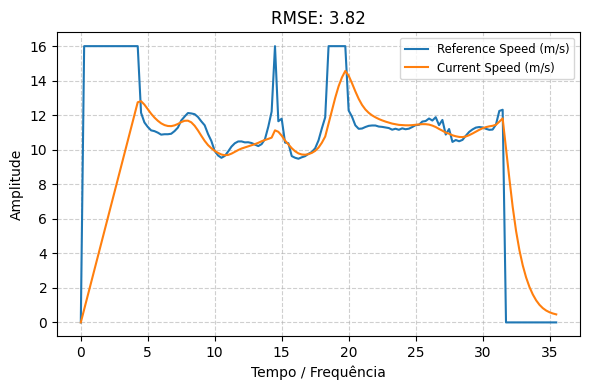

In [42]:
#PlotSeriesPLY(xSeries,ySeries,names,xLabel='Time (s)',title=f'Parameters Over Time|RMSE: {score}')
PlotSeriesPLT(xSeries[:2],ySeries[:2],names[:2],title=f'RMSE: {score:.2f}')
PlotSeriesPLY(xSeries,ySeries,names,xLabel='Time (s)',title=f'Parameters Over Time|RMSE: {score}')
PlotMPCTracksPLY(data,width=800,height=500)